currently have to work on the peak_labels() function. other 3 should be ready to go. might have to do minor adjusting. 

In [16]:
import matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.signal import find_peaks
from matplotlib.collections import LineCollection
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import utils
import nist_codes

try:
    import nist_helper
    descriptor_tokens = [t.lower() for t in getattr(nist_helper, "NIST_DESCRIPTORS", [])]
except Exception:
    nist_helper = None
    descriptor_tokens = []

In [17]:
HE_SHEET = "he test.xlsx"

df = pd.read_excel(HE_SHEET)
df_filtered = df[(df['nm'] >= 400) & (df['nm'] <= 750)].copy()

# Sort by 'nm' to ensure correct neighbor comparison and plotting order
df_filtered = df_filtered.sort_values(by='nm').reset_index(drop=True)

print("DataFrame loaded successfully. Here are the first 5 rows:")
print(df.head())

DataFrame loaded successfully. Here are the first 5 rows:
   Unnamed: 0  Grey Val         nm  Unnamed: 3    Unnamed: 4  Unnamed: 5  \
0        2178   247.148  589.03701         NaN  max grey val         NaN   
1        2179   246.463  587.91075         NaN       247.148         NaN   
2        2180   243.830  586.78449         NaN           NaN         NaN   
3        2181   241.833  585.65823         NaN  min grey val         NaN   
4        2177   240.733  590.16327         NaN        16.674         NaN   

   Unnamed: 6 Unnamed: 7  
0  3042.03129   -1.12626  
1         NaN        NaN  
2         NaN        NaN  
3         NaN        NaN  
4         NaN    he_3584  


In [18]:
min_int = df_filtered['Grey Val'].min()
max_int = df_filtered['Grey Val'].max()
int_range = max_int - min_int

rgb = utils.wavelength_to_rgb

y_title = 'Intensity'
x_title = 'Wavelength (nm)'
fig_size = (15,6)
prominence = 0.12
dyn_prom = prominence * int_range
min_bright = 0.1
min_alpha = 0.1
x_min = 400
x_max = 750
mode = 'dark'
reverse_x = True
show_grid = True

if int_range == 0:
    df_filtered['Normalized_int'] = 1.0
else:
    df_filtered['Normalized_int'] = (df_filtered['Grey Val'] - min_int) / int_range

In [19]:
def axis_labels():
    ax = plt.gca()

    if mode == 'dark':
        fig_bg = 'black'
        text = 'white'
        plt.gcf().set_facecolor('black')
        if show_grid is True:
            plt.grid(show_grid, color='darkgrey', linestyle=':', linewidth=0.5)
    else:
        fig_bg = 'white'
        text = 'black'
        if show_grid is True:
            plt.grid(show_grid)
    
    if reverse_x is True:
        plt.xlim(x_max, x_min)
    else:
        plt.xlim(x_min, x_max)

    ax.set_facecolor(fig_bg)
    plt.xlabel(x_title, color=text)
    plt.ylabel(y_title, color=text)
    plt.xticks(color=text)
    plt.yticks(color=text)

In [20]:
def final_alpha(alpha_min, alpha_factor):
    final_alpha = alpha_min + (1 - alpha_min) * alpha_factor
    return final_alpha

In [21]:
def line_plot_iteration():

    plt.figure(figsize=fig_size)    
    axis_labels()
    
    for i in range(len(df_filtered) - 1):
        wavelength_start = df_filtered.iloc[i]['nm']
        wavelength_end = df_filtered.iloc[i+1]['nm']

        int_factor = df_filtered.iloc[i]['Normalized_int']
        base_rgb = rgb(wavelength_start)

        final_intensity_scale = min_bright + (1 - min_bright) * int_factor

        colored_rgb = (base_rgb[0] * final_intensity_scale,
                    base_rgb[1] * final_intensity_scale,
                    base_rgb[2] * final_intensity_scale)

        plt.plot([wavelength_start, wavelength_end],
                [df_filtered.iloc[i]['Grey Val'], df_filtered.iloc[i+1]['Grey Val']],
                color=colored_rgb,
                linewidth=2)
    

In [22]:
def filled_plot_iteration():

    plt.figure(figsize=fig_size) 
    axis_labels()
    
    for i in range(len(df_filtered) - 1):
        wavelength_start = df_filtered.iloc[i]['nm']
        wavelength_end = df_filtered.iloc[i+1]['nm']

        base_rgb = rgb(wavelength_start)

        alpha_factor = df_filtered.iloc[i]['Normalized_int']
        alpha = final_alpha(min_alpha, alpha_factor)

        plt.fill_between([wavelength_start, wavelength_end],
                        [0, 0], # Base of the fill is y=0
                        [df_filtered.iloc[i]['Grey Val'], df_filtered.iloc[i+1]['Grey Val']], # Top of the fill
                        color=base_rgb,
                        alpha=alpha,
                        linewidth=0) # No line for the fill edges

        # Plot the line on top for clarity, using the base color for the line itself
        plt.plot([wavelength_start, wavelength_end],
                [df_filtered.iloc[i]['Grey Val'], df_filtered.iloc[i+1]['Grey Val']],
                color=base_rgb,
                linewidth=2) # Thicker line for better visibility on top of fill

In [23]:
def peak_labels():
    peaks, _ = find_peaks(df_filtered['Grey Val'], prominence=dyn_prom)
    for peak_index in peaks:
        row = df_filtered.iloc[peak_index]
        plt.annotate(f"{row['nm']:.2f} nm", # Formatted nm to two decimal places
                    (row['nm'], row['Grey Val']),
                    textcoords="offset points", # Offset the text
                    xytext=(0,10), # Distance from point to label
                    ha='center', # Horizontal alignment
                    bbox=dict(boxstyle="round,pad=0.3", fc="red", ec="b", lw=0.5, alpha=0.7),
                    arrowprops=dict(facecolor='black', shrink=0.05))

Calculated dynamic prominence: 27.39


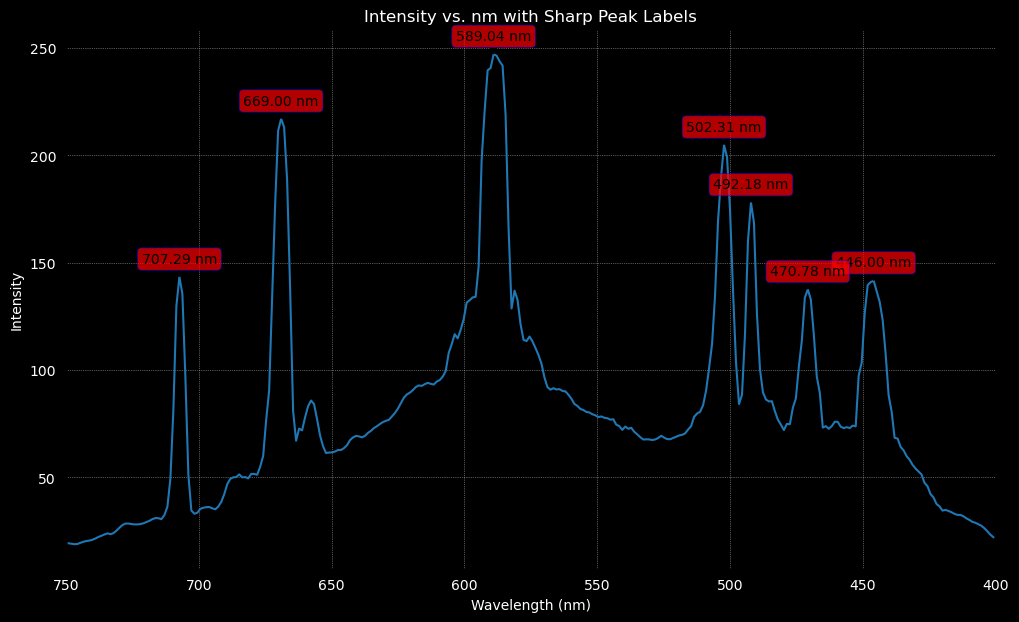

In [24]:
plt.figure(figsize=(12, 7))
sns.lineplot(data=df_filtered, x='nm', y='Grey Val', marker=None) 
plt.title('Intensity vs. nm with Sharp Peak Labels', color='white')

axis_labels()

print(f"Calculated dynamic prominence: {dyn_prom:.2f}")

peak_labels()
plt.show()

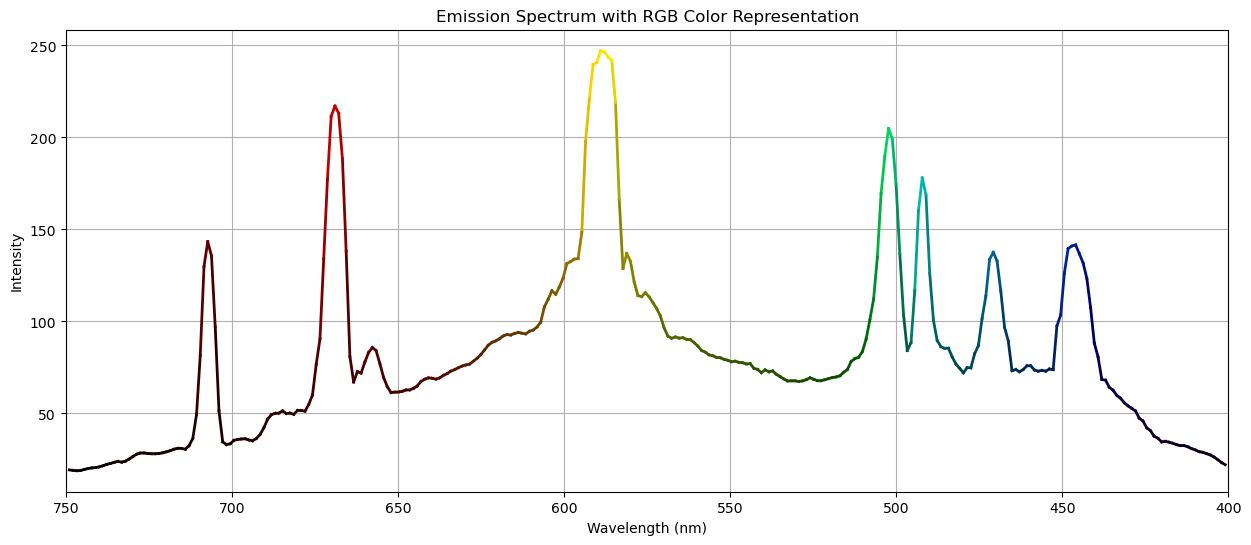

This plot displays the emission spectrum where each segment's color is determined by its wavelength, and its brightness is modulated by its 'Grey Val' (intensity).
The 'rgb' function maps wavelengths to corresponding colors in the visible spectrum, and the 'Normalized_int' adjusts the perceived brightness of these colors.


In [25]:
mode = 'light'
line_plot_iteration()

plt.title('Emission Spectrum with RGB Color Representation')

plt.show()

print("This plot displays the emission spectrum where each segment's color is determined by its wavelength, and its brightness is modulated by its 'Grey Val' (intensity).")
print("The 'rgb' function maps wavelengths to corresponding colors in the visible spectrum, and the 'Normalized_int' adjusts the perceived brightness of these colors.")

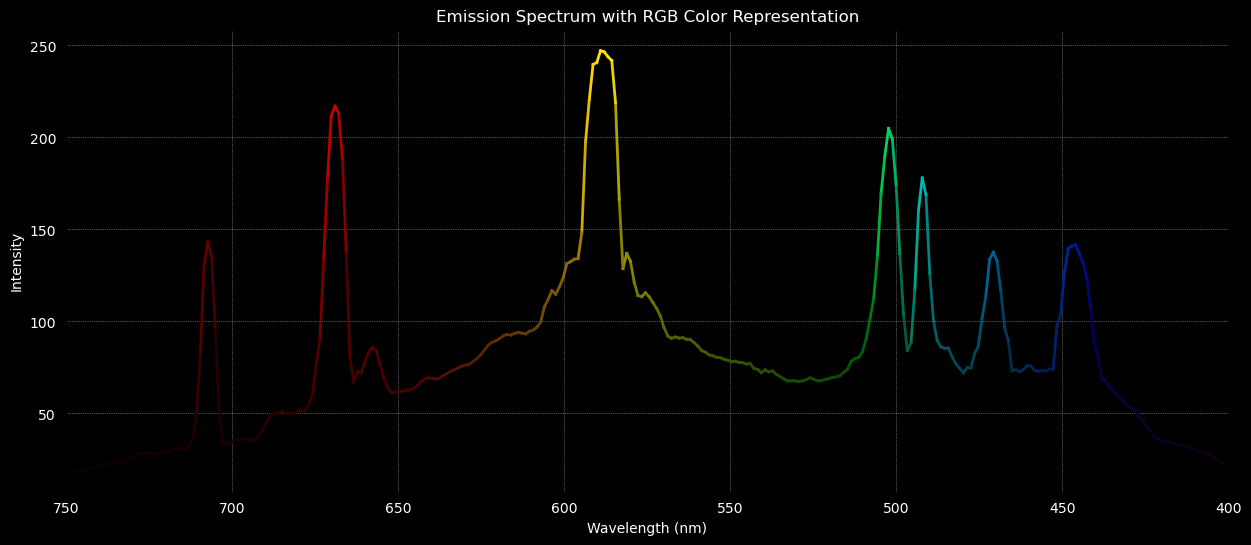

This plot displays the emission spectrum with a black background, using sharp, distinct lines.
The color of each line segment is determined by its wavelength, and its brightness is modulated by its 'Grey Val' (intensity), creating a visual representation similar to a traditional emission spectrum.


In [26]:
mode = 'dark'
show_grid = True
line_plot_iteration()

plt.title('Emission Spectrum with RGB Color Representation', color='white')

plt.show()

print("This plot displays the emission spectrum with a black background, using sharp, distinct lines.")
print("The color of each line segment is determined by its wavelength, and its brightness is modulated by its 'Grey Val' (intensity), creating a visual representation similar to a traditional emission spectrum.")

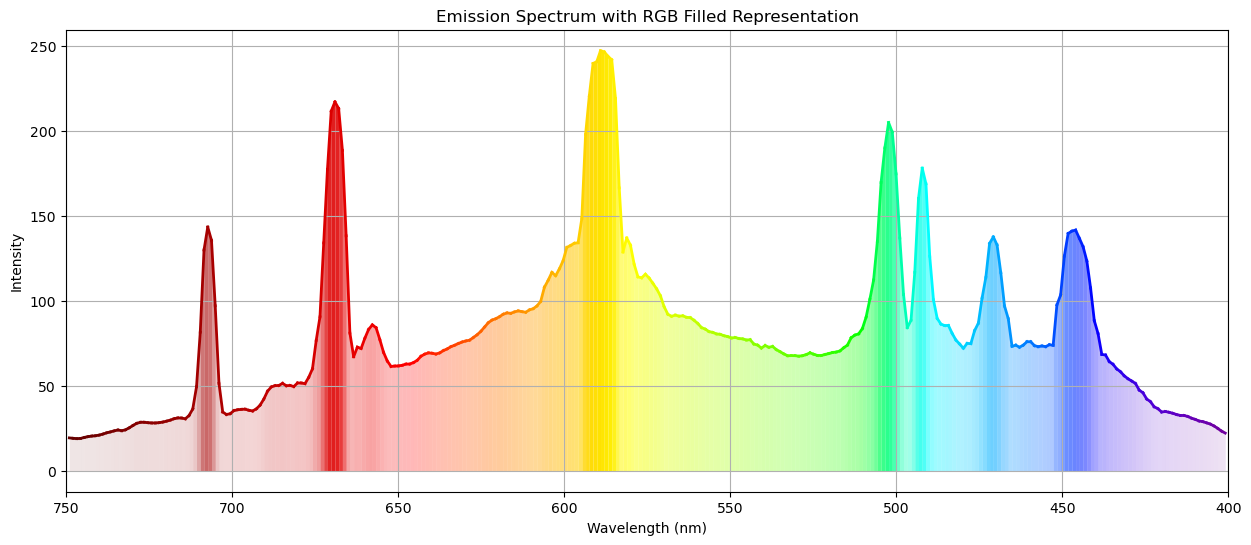

This plot now displays the emission spectrum with the area under the curve filled with wavelength-dependent colors.
The intensity of the emitted light (Grey Val) now directly influences the opacity (alpha) of the filled region, creating a more vivid 'glowing' effect for brighter emissions, similar to how emission spectra are often presented.


In [27]:
mode = 'light'
filled_plot_iteration()

plt.title('Emission Spectrum with RGB Filled Representation')

plt.show()

print("This plot now displays the emission spectrum with the area under the curve filled with wavelength-dependent colors.")
print("The intensity of the emitted light (Grey Val) now directly influences the opacity (alpha) of the filled region, creating a more vivid 'glowing' effect for brighter emissions, similar to how emission spectra are often presented.")

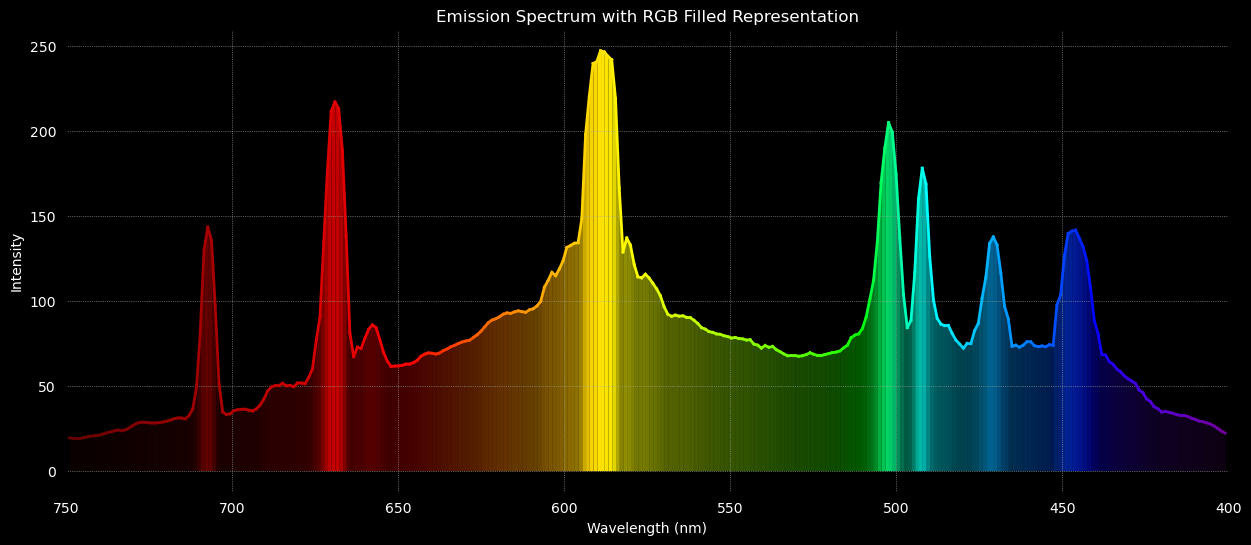

This plot now displays the emission spectrum with the area under the curve filled with wavelength-dependent colors, against a black background.
The intensity of the emitted light (Grey Val) now directly influences the opacity (alpha) of the filled region, creating a more vivid 'glowing' effect for brighter emissions.


In [28]:
mode = 'dark'
filled_plot_iteration()

plt.title('Emission Spectrum with RGB Filled Representation', color='white')

plt.show()

print("This plot now displays the emission spectrum with the area under the curve filled with wavelength-dependent colors, against a black background.")
print("The intensity of the emitted light (Grey Val) now directly influences the opacity (alpha) of the filled region, creating a more vivid 'glowing' effect for brighter emissions.")